# ActiveLoop Course

Reference: https://learn.activeloop.ai/courses/take/langchain/multimedia/46317639-course-introduction-things-you-should-know-before-you-start

In [ ]:
%pip install python_dotenv

Install the following libraries:

```
langchain==0.0.208
deeplake==3.6.5
openai==0.27.8
tiktoken==0.4.0
```

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
import os

In [ ]:
%pip install langchain==0.0.208 deeplake==3.6.5 openai==0.27.8 tiktoken==0.4.0

In [ ]:
import os

In [ ]:
# Set environment variables in collab
os.environ['OPENAI_API_KEY'] = "your_openapi_key"
os.environ["ACTIVELOOP_TOKEN"] = "your_activeloop_token"

LLMs are trained on huge amounts of text with the aim of learning the conditional distribution of words in a language. Doing so allows them to generalize and generate meaningful text without directly memorizing the training data. This means they can accurately recall widely disseminated information, such as historical events or popular cultural facts.

However, the LLM's knowledge is restricted to its training set. So, suppose the model was trained on data up to 2021 and is asked about a company founded in 2023. In that case, it may generate a plausible but entirely fabricated description - a phenomenon known as "hallucination.” Managing hallucinations is tricky, especially in applications where accuracy and reliability are paramount, such as customer-service chatbots, knowledge-base assistants, or AI tutors.

One promising strategy to mitigate hallucination is the use of retrievers in tandem with LLMs. A retriever fetches relevant information from a trusted knowledge base (like a search engine), and the LLM is then specifically prompted to rearrange the information without inventing additional details.

In [ ]:
from langchain.llms import OpenAI

In [ ]:
# Before executing the following code, make sure to have
# your OpenAI key saved in the “OPENAI_API_KEY” environment variable.
llm = OpenAI(model="text-davinci-003", temperature=0.9)

In [ ]:
text = "Suggest a personalized workout routine for someone looking to improve cardiovascular endurance and prefers outdoor activities."
print(llm(text))

## The Chains
In LangChain, a chain is an end-to-end wrapper around multiple individual components, providing a way to accomplish a common use case by combining these components in a specific sequence. The most commonly used type of chain is the LLMChain, which consists of a PromptTemplate, a model (either an LLM or a ChatModel), and an optional output parser.

**The LLMChain works as follows:**

1. Takes (multiple) input variables.
2. Uses the PromptTemplate to format the input variables into a prompt.
3. Passes the formatted prompt to the model (LLM or ChatModel).
4. If an output parser is provided, it uses the OutputParser to parse the output of the LLM into a final format.

In the next example, we demonstrate how to create a chain that generates a possible name for a company that produces eco-friendly water bottles. By using LangChain's LLMChain, PromptTemplate, and OpenAIclasses, we can easily define our prompt, set the input variables, and generate creative outputs.

In [ ]:
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.chains import LLMChain

In [ ]:
# Create the LLM object
llm = OpenAI(model='text-davinci-003', temperature=0.9)

In [ ]:
# Create the prompt template
prompt = PromptTemplate(
    input_variables=['product'],
    template="What is a good name for a company that makes {product}?",
)

In [ ]:
llm_chain = LLMChain(llm=llm, prompt=prompt)

In [ ]:
# Run the chain only specifying the input variable.
print(llm_chain.run("eco-friendly water bottles"))

In [ ]:
# Run the chain only specifying the input variable
print(llm_chain.run("eco-friendly food"))

## The Memory

In LangChain, Memory refers to the mechanism that stores and manages the conversation history between a user and the AI. It helps maintain context and coherency throughout the interaction, enabling the AI to generate more relevant and accurate responses. Memory, such as ConversationBufferMemory, acts as a wrapper around ChatMessageHistory, extracting the messages and providing them to the chain for better context-aware generation.

In [ ]:
from langchain.llms import OpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory

In [ ]:
llm = OpenAI(model="text-davinci-003", temperature=0)

In [ ]:
memory = ConversationBufferMemory()

In [ ]:
conversation = ConversationChain(
    llm=llm,
    verbose=True,
    memory=memory,
)

In [ ]:
# Start the conversation
conversation.predict(input="Hello, How are you?")

In [ ]:
conversation.memory

> Continue the conversation ........

In [ ]:
conversation.predict(input="I am fine. Tell me about yourself.")

In [ ]:
conversation.predict(input="What can you do?")

In [ ]:
conversation.predict(input="Can you explain what is vector db and how can I provide the database context to LLM via vector db?")

In [ ]:
conversation.predict(input="How can you help me with data analysis?")

In [ ]:
conversation.predict(input="Regarding which context we were talking?")

**1st Prompt**

**Human:** Hello, How are you?

**memory:**
ConversationBufferMemory(chat_memory=ChatMessageHistory(messages=[HumanMessage(content='Hello, How are you?', additional_kwargs={}, example=False))

**AI:** Hi there! I'm doing great. How about you?

**memory:**
ConversationBufferMemory(chat_memory=ChatMessageHistory(messages=[HumanMessage(content='Hello, How are you?', additional_kwargs={}, example=False), AIMessage(content=" Hi there! I'm doing great. How about you?", additional_kwargs={}, example=False))

**2nd Prompt**

**Human:** I am fine. Tell me about yourself.

**memory:**
ConversationBufferMemory(chat_memory=ChatMessageHistory(messages=[HumanMessage(content='Hello, How are you?', additional_kwargs={}, example=False), AIMessage(content=" Hi there! I'm doing great. How about you?", additional_kwargs={}, example=False), HumanMessage(content='I am fine. Tell me about yourself.', additional_kwargs={}, example=False))

.. and like this each Human and AI prompt will be inserted in memory

**AI:** Sure! I'm an AI created to help people with their everyday tasks. I'm programmed to understand natural language and provide helpful information. I'm also able to learn from my interactions with people, so I'm constantly growing and improving. What else would you like to know?

**3rd prompt**
......

```
Current conversation:
Human: Hello, How are you?
AI:  Hi there! I'm doing great. How about you?
Human: I am fine. Tell me about yourself.
AI:  Sure! I'm an AI created to help people with their everyday tasks. I'm programmed to understand natural language and provide helpful information. I'm also able to learn from my interactions with people, so I'm constantly growing and improving. What else would you like to know?
Human: What can you do?
AI:  I can help with a variety of tasks, such as providing information, answering questions, and helping with scheduling. I'm also able to provide personalized recommendations based on your preferences.
Human: Can you explain what is vector db and how can I provide the database context to LLM via vector db?
AI:  I'm sorry, I don't know the answer to that question.
Human: How can you help me with data analysis?
AI:  Sure! I can help you with data analysis by providing insights and recommendations based on the data you provide. I can also help you visualize the data in a way that makes it easier to understand.
Human: Regarding which context we were talking?
AI: We were talking about my capabilities and how I can help with data analysis.
```

As observe in the above conversation that the context is maintained throughout the conversation. In this output, you can see the memory being used by observing the "Current conversation" section. After each input from the user, the conversation is updated with both the user's input and the AI's response. This way, the memory maintains a record of the entire conversation. When the AI generates its next response, it will use this conversation history as context, making its responses more coherent and relevant.

In [ ]:
# Display the conversation
print(conversation)

## Deep Lake VectorStore
Deep Lake provides storage for embeddings and their corresponding metadata in the context of LLM apps. It enables hybrid searches on these embeddings and their attributes for efficient data retrieval. It also integrates with LangChain, facilitating the development and deployment of applications.

Deep Lake provides several advantages over the typical vector store:

* It’s multimodal, which means that it can be used to store items of diverse modalities, such as texts, images, audio, and video, along with their vector representations.
* It’s serverless, which means that we can create and manage cloud datasets without creating and managing a database instance. This aspect gives a great speedup to new projects.
* Last, it’s possible to easily create a data loader out of the data loaded into a Deep Lake dataset. It is convenient for fine-tuning machine learning models using common frameworks like PyTorch and TensorFlow.

In [ ]:
%pip install deeplake

In [ ]:
from langchain.embeddings import OpenAIEmbeddings
from langchain.llms import OpenAI
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import DeepLake
from langchain.chains import RetrievalQA

In [ ]:
# Let's create the llm model
llm = OpenAI(model='text-davinci-003', temperature=0)

1. Embeddings: https://platform.openai.com/docs/guides/embeddings/what-are-embeddings

Text embeddings are an essential tool in the field of natural language processing (NLP). They are numerical representations of text where each word or phrase is represented as a dense vector of real numbers.

The significant advantage of these embeddings is their ability to capture semantic meanings and relationships between words or phrases, which enables machines to understand and process human language efficiently.

Text embeddings are crucial in scenarios like text classification, information retrieval, and semantic similarity detection.


```
from langchain.embeddings import OpenAIEmbeddings
```

The OpenAIEmbeddings is used to generate embeddings based on the text

In [ ]:
# Create the embedding object
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

```
from langchain.text_splitter import RecursiveCharacterTextSplitter
```

The RecursiveCharacterTextSplitter takes a large text and splits it based on a specified chunk size. It does this by using a set of characters. The default characters provided to it are ["\n\n", "\n", " ", ""].

It takes in the large text then tries to split it by the first character \n\n. If the first split by \n\n is still large then it moves to the next character which is \n and tries to split by it. If it is still larger than our specified chunk size it moves to the next character in the set until we get a split that is less than our specified chunk size.

In [ ]:
# Create our documents
text = [
    "Napoleon Bonaparte was born in 15 August 1769",
    "Louis XIV was born in 5 September 1638"
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0)

In [ ]:
# Let's check how the text are splitted
# texts = text_splitter.split_text(text[0])
# print(len(texts))
# print(texts[4])

In [ ]:
docs = text_splitter.create_documents(text)

In [ ]:
docs

In [ ]:
from dotenv import load_dotenv

load_dotenv()

In [ ]:
# create Deep Lake dataset
# use your organization id here. (by default, org id is your username)
my_activeloop_org_id = os.environ.get("my_activeloop_org_id")
my_activeloop_dataset_name = os.environ.get("my_activeloop_dataset_name")
dataset_path = f"hub://{my_activeloop_org_id}/{my_activeloop_dataset_name}"

In [ ]:
db = DeepLake(dataset_path=dataset_path, embedding_function=embedding)

In [ ]:
# add documents to our Deep Lake dataset
db.add_documents(docs)

### Now let's create a RetreivalQA object

### What is RetrievalQA?

Reference: https://www.linkedin.com/pulse/transforming-question-answering-openai-langchain-harnessing-routu/

Retrieval augmented generation (RAG) is a powerful approach that combines the capabilities of language models with the ability to retrieve relevant information from external documents. In RAG, a language model retrieves contextual documents from an external dataset to enhance its understanding and generate more accurate and informative responses.
This retrieval-based approach is particularly useful when we want to ask questions or generate content based on specific documents such as PDFs, videos, web pages, or even Notion databases. By incorporating external documents into the language model's execution, RAG expands its knowledge and provides more contextually rich output

In [ ]:
retrievalqa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=db.as_retriever()
)

In [ ]:
# Next, let's create an agent that uses the RetrievalQA chain as a tool:
from langchain.agents import initialize_agent, Tool
from langchain.agents import AgentType

In [ ]:
tools = [
    Tool(
        name="Retrieval QA System",
        func=retrievalqa.run,
        description="Useful for answerignq uestions."
    )
]

In [ ]:
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

In [ ]:
agent.run("When was Napoleone born?")

This example demonstrates how to use Deep Lake as a vector database and create an agent with a RetrievalQA chain as a tool to answer questions based on the given document.

Let’s add an example of reloading an existing vector store and adding more data.

We first reload an existing vector store from Deep Lake that's located at a specified dataset path. Then, we load new textual data and split it into manageable chunks. Finally, we add these chunks to the existing dataset, creating and storing corresponding embeddings for each added text segment:

In [ ]:
db = DeepLake(dataset_path=dataset_path, embedding_function=embedding)

In [ ]:
# create new documents
texts = [
    "Lady Gaga was born in 28 March 1986",
    "Michael Jeffrey Jordan was born in 17 February 1963"
]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

In [ ]:
docs = text_splitter.create_documents(texts)

In [ ]:
docs

In [ ]:
# Now add this to DeepLake
db.add_documents(docs)

In [ ]:
# instantiate the wrapper class for GPT3
llm = OpenAI(model="text-davinci-003", temperature=0)

***stuff chain***

Stuff Document Chain is a pre-made chain provided by LangChain that is configured for summarization. Behind the scenes it uses a T5 model. The benefits is we don't have to configure the prompt or the Large Language Model (LLM). It provides an out-of-the-box summarization solution for LangChain.

In [ ]:
retrieval_qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=db.as_retriever()
)

In [ ]:
tools = [
    Tool(
        name="Retrieval QA System",
        func=retrieval_qa.run,
        description="Useful for answerignq uestions."
    )
]

In [ ]:
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

In [ ]:
agent.run("In which year Lady gaga was born?")

In [ ]:
agent.run("When was Michael jeffrey born?")

In [ ]:
agent.run("Who is Michael Jeffrey Jordan?")

**Tracking Token Usage**

You can use the LangChain library's callback mechanism to track token usage. This is currently implemented only for the OpenAI API:

In [ ]:
from langchain.llms import OpenAI
from langchain.callbacks import get_openai_callback

llm = OpenAI(model_name="text-davinci-003", n=2, best_of=2)

with get_openai_callback() as cb:
    result = llm("Tell me a joke")
    print(cb)
    print(result)

The callback will track the tokens used, successful requests, and total cost.

# Few-shot learning

Few-shot learning is a remarkable ability that allows LLMs to learn and generalize from limited examples. Prompts serve as the input to these models and play a crucial role in achieving this feature. With LangChain, examples can be hard-coded, but dynamically selecting them often proves more powerful, enabling LLMs to adapt and tackle tasks with minimal training data swiftly.

This approach involves using the FewShotPromptTemplateCopy class, which takes in a PromptTemplateCopy and a list of a few shot examples. The class formats the prompt template with a few shot examples, which helps the language model generate a better response. We can streamline this process by utilizing LangChain's FewShotPromptTemplate to structure the approach:

In [ ]:
from langchain import PromptTemplate
from langchain import FewShotPromptTemplate

In [ ]:
# create our examples
examples = [
    {
        "query": "What's the weather like?",
        "answer": "It's raining cats and dogs, better bring an umbrella!"
    }, {
        "query": "How old are you?",
        "answer": "Age is just a number, but I'm timeless."
    }
]

In [ ]:
# create an example template
example_template = """
  User: {query}
  AI: {answer}
"""

In [ ]:
# create a prompt example from above template
example_prompt = PromptTemplate(
    input_variables=["query", "answer"],
    template=example_template
)

In [ ]:
# now break our previous prompt into a prefix and suffix
# the prefix is our instructions
prefix = """The following are excerpts from conversations with an AI
assistant. The assistant is known for its humor and wit, providing
entertaining and amusing responses to users' questions. Here are some
examples:
"""

In [ ]:
# and the suffix our user input and output indicator
suffix = """
User: {query}
AI: """

In [ ]:
# now create the few-shot prompt template
few_shot_prompt_template = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    prefix=prefix,
    suffix=suffix,
    input_variables=["query"],
    example_separator="\n\n"
)

After creating a template, we pass the example and user query, and we get the results

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain import LLMChain

In [ ]:
# load the model
llm = ChatOpenAI(model_name="gpt-4", temperature=0.0)

In [ ]:
chain = LLMChain(llm=llm, prompt=few_shot_prompt_template)

In [ ]:
print(chain.run("What's the meaning of life?"))

#### Examples with Easy Prompts: Text Summarization, Text Translation, and Question Answering

In the realm of natural language processing, Large Language Models have become a popular tool for tackling various text-based tasks. These models can be promoted in different ways to produce a range of results, depending on the desired outcome.

In [ ]:
%pip install -q huggingface_hub

#### Creating a Question-Answering Prompt Template

In [ ]:
from langchain import PromptTemplate

In [ ]:
template = """
  User: {question}
  AI:
"""

In [ ]:
prompt_template = PromptTemplate(
    template=template,
    input_variables=["question"]
)

Next, we will use the Hugging Face model google/flan-t5-large to answer the question. The HuggingfaceHub class will connect to Hugging Face’s inference API and load the specified model.

In [ ]:
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = "paste your hugging_face api token"

In [ ]:
from langchain import HuggingFaceHub, LLMChain

In [ ]:
# initialize hugging face hub
hub_llm = HuggingFaceHub(
    repo_id='google/flan-t5-large',
    model_kwargs={'temperature': 0}
)

In [ ]:
llm_chain = LLMChain(
    llm=hub_llm,
    prompt=prompt_template
)

In [ ]:
# user question
question = "What is the capital city of France?"

In [ ]:
print(llm_chain.run(question))

We can also modify the prompt template to include multiple questions.

**Asking Multiple Questions**

To ask multiple questions, we can either iterate through all questions one at a time or place all questions into a single prompt for more advanced LLMs.

In [ ]:
qa = [
    {'question': "What is the capital city of France?"},
    {'question': "What is the largest mammal on Earth?"},
    {'question': "Which gas is most abundant in Earth's atmosphere?"},
    {'question': "What color is a ripe banana?"}
]

In [ ]:
res = llm_chain.generate(qa)
print(res)

We can modify our prompt template to include multiple questions to implement a second approach. The language model will understand that we have multiple questions and answer them sequentially. This method performs best on more capable models.

In [ ]:
multi_template = """Answer the following questions one at a time.

Questions:
{questions}

Answers:
"""

In [ ]:
multi_template_prompt = PromptTemplate(
    template=multi_template,
    input_variables=["questions"]
)

In [ ]:
multipl_prompt_llm_chain = LLMChain(
    llm=hub_llm,
    prompt=multi_template_prompt
)

In [ ]:
qa_str = (
    "What is the capital city of France?\n" +
    "What is the largest mammal on Earth?\n" +
    "Which gas is most abundant in Earth's atmosphere?\n" +
		"What color is a ripe banana?\n"
)

In [ ]:
print(qa_str)

In [ ]:
print(multipl_prompt_llm_chain.run(qa_str))

# Exploring Conversational Capabilities with GPT-4 and ChatGPT

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.schema import (
    SystemMessage,
    HumanMessage,
    AIMessage
)

messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="What is the capital of France?"),
    AIMessage(content="The capital of France is Paris.")
]

In [ ]:
prompt = HumanMessage(content="I'd like to know more about the city you just mentioned.")

In [ ]:
messages.append(prompt)

In [ ]:
messages

In [ ]:
llm = ChatOpenAI(model_name='gpt-4')

In [ ]:
response = llm(messages)

In [ ]:
response

In [ ]:
messages = [
    SystemMessage(content="You are a helpful assistant. If don't aware regarding any answer then reply Sorry I don't know."),
    HumanMessage(content="What is my name?"),
    # AIMessage(content="The capital of France is Paris.")
]

In [ ]:
llm(messages)

> Here the content is provided that what is my name that GPT is unaware of, so it returned the result Sorry I don't know, as mentioned in the context.

The **SystemMessage** provides context for the conversation, while **HumanMessage** and **AIMessage** represent the user and the AI's messages, respectively.

# Build a News Articles Summarizer

In [ ]:
%pip install -q newspaper3k python-dotenv

In [ ]:
import requests
from newspaper import Article

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4389.82 Safari/537.36'
}

article_url = "https://www.artificialintelligence-news.com/2022/01/25/meta-claims-new-ai-supercomputer-will-set-records/"

session = requests.Session()

try:
    response = session.get(article_url, headers=headers, timeout=10)

    if response.status_code == 200:
        article = Article(article_url)
        article.download()
        article.parse()

        print(f"Title: {article.title}")
        print(f"Text: {article.text}")

    else:
        print(f"Failed to fetch article at {article_url}")
except Exception as e:
    print(f"Error occurred while fetching article at {article_url}: {e}")

In [ ]:
from langchain.schema import HumanMessage

article_title = article.title
article_text = article.text

In [ ]:
template = """You are a very good assistant that summarizes online articles.

Here's the article you want to summarize.

==================
Title: {article_title}

{article_text}
==================

Write a summary of the previous article.
"""

In [ ]:
prompt = template.format(article_title=article_title, article_text=article_text)

In [ ]:
messages = [HumanMessage(content=prompt)]

In [ ]:
from langchain.chat_models import ChatOpenAI

In [ ]:
chat = ChatOpenAI(model_name='gpt-4', temperature=0, verbose=True)

In [ ]:
chat(messages)

# Exploring the Role of Langchain's Indexes and Retrievers

In [ ]:
from langchain.document_loaders import TextLoader

text = """Google opens up its AI language model PaLM to challenge OpenAI and GPT-3
Google is offering developers access to one of its most advanced AI language models: PaLM.
The search giant is launching an API for PaLM alongside a number of AI enterprise tools
it says will help businesses “generate text, images, code, videos, audio, and more from
simple natural language prompts.”

PaLM is a large language model, or LLM, similar to the GPT series created by OpenAI or
Meta's LLaMA family of models. Google first announced PaLM in April 2022. Like other LLMs,
PaLM is a flexible system that can potentially carry out all sorts of text generation and
editing tasks. You could train PaLM to be a conversational chatbot like ChatGPT, for
example, or you could use it for tasks like summarizing text or even writing code.
(It's similar to features Google also announced today for its Workspace apps like Google
Docs and Gmail.)
"""

with open("my_file.txt", "w") as f:
  f.write(text)

In [ ]:
loader = TextLoader("my_file.txt")
docs_from_file = loader.load()

In [ ]:
print(docs_from_file)

In [ ]:
# Now split this text into smaller chunks
from langchain.text_splitter import CharacterTextSplitter

text_splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20
)

In [ ]:
doc = text_splitter.split_documents(docs_from_file)

In [ ]:
print(doc)

In [ ]:
len(doc)

In [ ]:
# create object os OpenAIEmbeddings
from langchain.embeddings import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

In [ ]:
# Let’s create an instance of a Deep Lake dataset.
from langchain.vectorstores import DeepLake

# Before executing the following code, make sure to have your
# Activeloop key saved in the “ACTIVELOOP_TOKEN” environment variable.

# create Deep Lake dataset
# TODO: use your organization id here. (by default, org id is your username)
my_activeloop_org_id = os.environ.get("my_activeloop_org_id")
my_activeloop_dataset_name = os.environ.get("my_activeloop_dataset_name")
dataset_path = f"hub://{my_activeloop_org_id}/{my_activeloop_dataset_name}"

# Create db instance
db = DeepLake(dataset_path=dataset_path, embedding_function=embeddings)

In [ ]:
db.add_documents(doc)

In this example, we are adding text documents to the dataset. However, being Deep Lake multimodal, we could have also added images to it, specifying an image embedder model. This could be useful for searching images according to a text query or using an image as a query (and thus looking for similar images).

As datasets become bigger, storing them in local memory becomes less manageable. In this example, we could have also used a local vector store, as we are uploading only two documents. However, in a typical production scenario, thousands or millions of documents could be used and accessed from different programs, thus having the need for a centralized cloud dataset.

In [ ]:
# create retriever from db
retriever = db.as_retriever()

In [ ]:
# Once we have the retriever, we can start with question-answering.
from langchain.chains import RetrievalQA
from langchain.llms import OpenAI

# Create llm object
llm = OpenAI(model_name="text-davinci-003")

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever
)

In [ ]:
response = qa_chain.run("How Google plans to challenge OpenAI?")
print(response)

In [ ]:
qa_chain.run("Google is challenging whom?")

In [ ]:
qa_chain.run("Google is challenging whom and why?")

In [ ]:
qa_chain.run("Why Google is challenging OpenAI and GPT-3?")

We can identify that the model doesn't have the answer of ```Why Google is challenging OpenAI and GPT-3?``` beacuse that is not mentioned in the document, that we have stored in the vectore store.

This method has a downside: you might not know how to get the right documents later when storing data. In the Q&A example, we cut the text into equal parts, causing both useful and useless text to show up when a user asks a question.

Including unrelated information in the LLM prompt is detrimental because:

It can divert the LLM's focus from pertinent details.
It occupies valuable space that could be utilized for more relevant information.

**Possible Solution**

A DocumentCompressor abstraction has been introduced to address this issue, allowing compress_documents on the retrieved documents.

The ContextualCompressionRetriever is a wrapper around another retriever in LangChain. It takes a base retriever and a DocumentCompressor and automatically compresses the retrieved documents from the base retriever. This means that only the most relevant parts of the retrieved documents are returned, given a specific query.

A popular compressor choice is the LLMChainExtractor, which uses an LLMChain to extract only the statements relevant to the query from the documents. To improve the retrieval process, a ContextualCompressionRetriever is used, wrapping the base retriever with an LLMChainExtractor. The LLMChainExtractor iterates over the initially returned documents and extracts only the content relevant to the query.

Here's an example of how to use ContextualCompressionRetriever with LLMChainExtractor:

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.prompts import PromptTemplate

In [ ]:
llm = OpenAI(model_name="text-davinci-003")

The template supports any number of variables, including no variables:

In [ ]:
# template = """Your are a helpful assitant that answers the query of the users.
# Try your best to answer the user's queries, in case if you don't have the answer, reply with Sorry I don't know!
# """

In [ ]:
# prompt_template = PromptTemplate.from_template(
#     template=template,
#     )

In [ ]:
compressor = LLMChainExtractor.from_llm(llm) #, prompt=prompt_template)

In [ ]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=retriever
)

Once we have created the compression_retriever, we can use it to retrieve the compressed relevant documents to a query.

In [ ]:
# retrieving compressed documents
retrieved_docs = compression_retriever.get_relevant_documents(
	query="How Google plans to challenge OpenAI?"
)

In [ ]:
retrieved_docs[0].page_content

# Streamlined Data Ingestion: Text, PyPDF, Selenium URL Loaders, and Google Drive Sync

In [ ]:
%pip install -q pypdf

In [ ]:
from langchain.document_loaders import PyPDFLoader

In [ ]:
loader = PyPDFLoader("gspread.pdf")
pages = loader.load_and_split()

In [ ]:
# Pdf is splitted page wise
print(pages[0])

In [ ]:
from langchain.text_splitter import CharacterTextSplitter

text_splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20
)

In [ ]:
docs = text_splitter.split_documents(pages)

In [ ]:
len(docs)

In [ ]:
from langchain.embeddings import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

In [ ]:
from langchain.vectorstores import DeepLake

my_activeloop_org_id = os.environ.get("my_activeloop_org_id")
my_activeloop_dataset_name = os.environ.get("my_activeloop_dataset_name")
dataset_path = f"hub://{my_activeloop_org_id}/{my_activeloop_dataset_name}"

In [ ]:
# create deeplake object
db = DeepLake(dataset_path=dataset_path, embedding_function=embeddings)

In [ ]:
db.add_documents(docs)

In [ ]:
# create retriever from db
retriever = db.as_retriever()

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.llms import OpenAI

In [ ]:
llm = OpenAI(model_name="text-davinci-003")

In [ ]:
# create compressor using LLMChainExtractor
compressor = LLMChainExtractor.from_llm(llm)

In [ ]:
# create compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=retriever
)

In [ ]:
response = compression_retriever.get_relevant_documents(
    "What is Authentication in gspread?"
)

In [ ]:
print(response[2].page_content)

In [ ]:
response = compression_retriever.get_relevant_documents(
    "How to enable API Access for a Project"
)

In [ ]:
print(response[0].page_content)

Above we can see that how it gave the correct and relevant output, the one that is mentioned in the pdf.
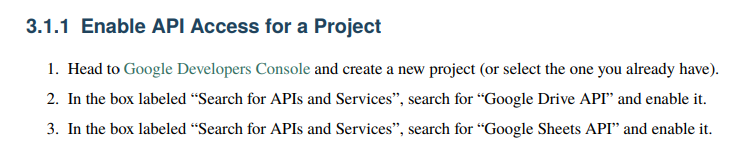